# Hotstart and chained runs

**What this shows:** how to split a simulation into runs that follow on from each
other: the first run writes its state, and the next one starts from it instead of
from rest.

**Prerequisites:** [Tutorial 5: Choosing model settings](../tutorial/05_model_settings.ipynb)
and [Running SCHISM](running_schism.ipynb).

**You will learn:**

- how to make SCHISM write hotstart files (`nhot`, `nhot_write`)
- how to combine them into one `hotstart.nc` with `combine_hotstart7`
- how to start the next run from it (`ihot`), without a second ramp
- how much a hotstart saves compared with a cold start

**Data used:** `hgrid.gr3` and `tides/`. The runs need Docker and are skipped
without it.

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from rompy.backends import DockerConfig
from rompy.core.data import DataBlob
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy.model import ModelRun

from rompy_schism.boundary_core import TidalDataset
from rompy_schism.config import SCHISMConfig
from rompy_schism.data import (
    BoundarySetupWithSource,
    SCHISMData,
    SCHISMDataBoundaryConditions,
)
from rompy_schism.grid import SCHISMGrid
from rompy_schism.namelists import NML, Param

logging_config.update(level="ERROR")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "hotstart_and_chained_runs"
shutil.rmtree(OUT_DIR, ignore_errors=True)
SCHISM_IMAGE = "ghcr.io/rom-py/schism:5.13.0"

grid = SCHISMGrid(hgrid=DataBlob(source=DATA_DIR / "hgrid.gr3"), drag=0.0025)
data = SCHISMData(
    boundary_conditions=SCHISMDataBoundaryConditions(
        tidal_data=TidalDataset(
            tidal_database=DATA_DIR / "tides",
            tidal_model="TPXO9-perth",
            constituents=["M2", "S2", "N2", "K2", "K1", "O1", "P1", "Q1"],
            nodal_corrections=True,
        ),
        default_boundary=BoundarySetupWithSource(elev_type=3, vel_type=3),
    )
)
core = {"ibc": 1, "ibtp": 0, "dt": 120.0, "nspool": 15, "ihfskip": 720}
schout = {"iof_hydro__1": 1, "iof_hydro__16": 1, "iof_hydro__26": 0}


def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


def run_completed(workspace: Path) -> bool:
    """Check SCHISM's log: SCHISM exits with success even when it stops on an error."""
    mirror = workspace / "outputs" / "mirror.out"
    if mirror.exists() and "Run completed successfully" in mirror.read_text():
        return True
    fatal = workspace / "outputs" / "fatal.error"
    print(fatal.read_text() if fatal.exists() else "SCHISM did not finish")
    return False


def open_out2d(workspace: Path) -> xr.Dataset:
    """All stacks of a run's 2D output."""
    return xr.open_mfdataset(
        sorted((workspace / "outputs").glob("out2d_*.nc")),
        data_vars="minimal", coords="minimal", compat="override",
    )  # fmt: skip


backend = DockerConfig(image=SCHISM_IMAGE, executable="schism 2", mpiexec="mpirun", cpu=6)
DOCKER = docker_available()

## 1. Writing hotstart files

A hotstart file holds the full state of the model at one time step: water levels,
velocities, and temperature and salinity in 3D. SCHISM writes one when
`schout.nhot=1`, every `nhot_write` time steps, which must be a multiple of
`ihfskip`.

The first run covers 1 and 2 January and writes a hotstart every day: with
`dt=120` s, a day is 720 steps.

In [2]:
first = ModelRun(
    run_id="first",
    period=TimeRange(start="2023-01-01T00:00", end="2023-01-03T00:00", interval="1h"),
    output_dir=OUT_DIR,
    config=SCHISMConfig(
        grid=grid,
        data=data,
        nml=NML(param=Param(core=core, schout={**schout, "nhot": 1, "nhot_write": 720})),
    ),
)
first_workspace = Path(first())
if DOCKER:
    first.run(backend, workspace_dir=first_workspace)
first_completed = run_completed(first_workspace)
if first_completed:
    print(sorted(p.name for p in (first_workspace / "outputs").glob("hotstart_*")))

['hotstart_000000_1440.nc', 'hotstart_000000_720.nc', 'hotstart_000001_1440.nc', 'hotstart_000001_720.nc', 'hotstart_000002_1440.nc', 'hotstart_000002_720.nc', 'hotstart_000003_1440.nc', 'hotstart_000003_720.nc']


## 2. Combining them

Each compute process writes its own part of the mesh, as
`hotstart_<process>_<step>.nc`. `combine_hotstart7`, which comes with SCHISM and is
in the Docker image, merges the parts of one time step (`-i`) into
`hotstart_it=<step>.nc`. Step 720 is the end of 1 January.

In [3]:
outputs = (first_workspace / "outputs").resolve()
if first_completed:
    subprocess.run(
        ["docker", "run", "--rm", "-v", f"{outputs}:/outputs", "-w", "/outputs",
         SCHISM_IMAGE, "combine_hotstart7", "-i", "720"],
        capture_output=True, check=True,
    )  # fmt: skip
    hotstart = xr.open_dataset(outputs / "hotstart_it=720.nc")
    print(hotstart[["time", "eta2", "su2", "tr_nd"]])

<xarray.Dataset> Size: 588kB
Dimensions:  (one_new: 1, node: 6790, side: 19750, nVert: 2, ntracers: 2)
Dimensions without coordinates: one_new, node, side, nVert, ntracers
Data variables:
    time     (one_new) float64 8B ...
    eta2     (node) float64 54kB ...
    su2      (side, nVert) float64 316kB ...
    tr_nd    (node, nVert, ntracers) float64 217kB ...


## 3. Starting from the hotstart

The second run covers 2 January only. It starts from `hotstart.nc` in its workspace:

- **`opt.ihot=1`**: read `hotstart.nc` and start the clock at zero, at the start of
  this run. Each run then has its own period, and rompy-schism writes its forcing
  for that period as usual. (`ihot=2` continues the clock of the first run instead.)
- **`opt.dramp=0`**: no ramp. The model is already moving; ramping the boundary
  forcing up from zero again would disturb it.

rompy-schism does not take a hotstart file from a previous run, so it is copied into
the workspace before SCHISM runs. For comparison, a third run covers 2 January from a
cold start: from rest, with the usual one-day ramp.

In [4]:
day2 = TimeRange(start="2023-01-02T00:00", end="2023-01-03T00:00", interval="1h")
second = ModelRun(
    run_id="second",
    period=day2,
    output_dir=OUT_DIR,
    config=SCHISMConfig(
        grid=grid,
        data=data,
        nml=NML(param=Param(core=core, opt={"ihot": 1, "dramp": 0.0}, schout=schout)),
    ),
)
cold = ModelRun(
    run_id="cold",
    period=day2,
    output_dir=OUT_DIR,
    config=SCHISMConfig(grid=grid, data=data, nml=NML(param=Param(core=core, schout=schout))),
)
second_workspace, cold_workspace = Path(second()), Path(cold())
results = {}
if first_completed:
    shutil.copy(outputs / "hotstart_it=720.nc", second_workspace / "hotstart.nc")
    for name, (modelrun, workspace) in {
        "hotstart": (second, second_workspace), "cold start": (cold, cold_workspace)
    }.items():  # fmt: skip
        modelrun.run(backend, workspace_dir=workspace)
        if run_completed(workspace):
            results[name] = open_out2d(workspace)
    results["continuous"] = open_out2d(first_workspace).sel(time=slice("2023-01-02", None))
print(f"Completed: {list(results)}")

Completed: ['hotstart', 'cold start', 'continuous']


## 4. Compare

On 2 January, the run started from the hotstart follows the continuous run: the
water level at Fremantle is within a few centimetres. The currents take a few hours
to settle, a few cm/s at the fastest point, and then match too. The cold start
begins from rest and ramps the tide up over the day: its water level is up to 0.3 m
off, and it only catches up in the afternoon. Without a hotstart, every run in a
chain needs its own spin-up.

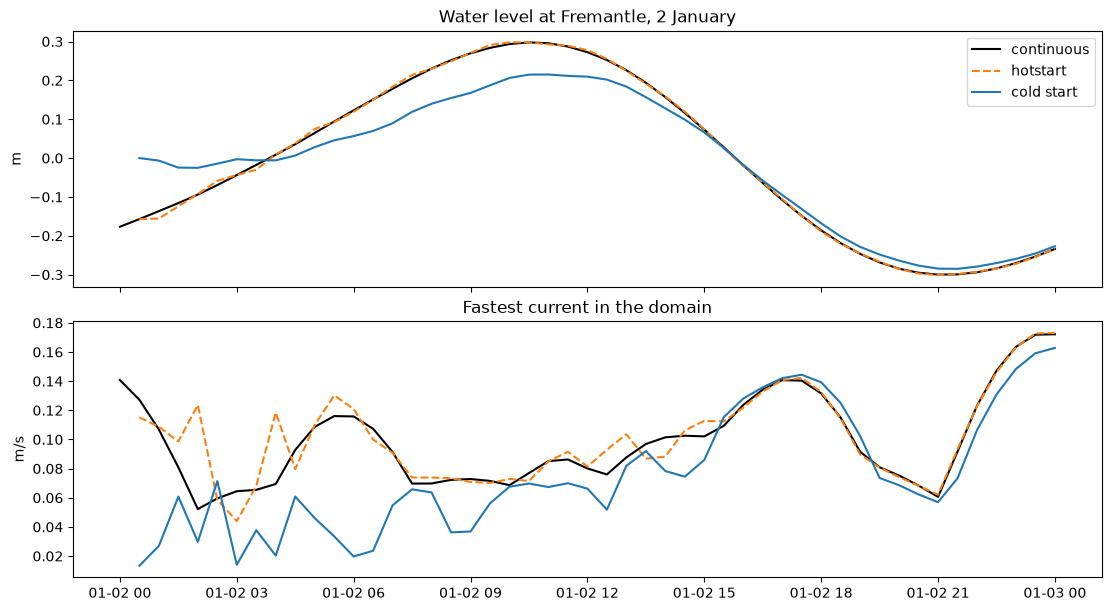

In [5]:
if len(results) == 3:
    out = results["continuous"]
    x, y = out.SCHISM_hgrid_node_x.values, out.SCHISM_hgrid_node_y.values
    fremantle = np.argmin((x - 115.72) ** 2 + (y + 32.06) ** 2)
    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, layout="constrained")
    styles = {"continuous": "k-", "hotstart": "C1--", "cold start": "C0-"}
    for name, style in styles.items():
        result = results[name]
        axes[0].plot(result.time, result.elevation[:, fremantle], style, label=name)
        speed = np.hypot(result.depthAverageVelX, result.depthAverageVelY)
        axes[1].plot(result.time, speed.max("nSCHISM_hgrid_node"), style, label=name)
    axes[0].set(title="Water level at Fremantle, 2 January", ylabel="m")
    axes[1].set(title="Fastest current in the domain", ylabel="m/s")
    axes[0].legend()

In [6]:
if len(results) == 3:
    for name in ["hotstart", "cold start"]:
        # xarray matches the times of the two runs
        difference = abs(results[name].elevation - results["continuous"].elevation)
        print(f"{name}: largest water level difference {float(difference.max()):.3f} m")

hotstart: largest water level difference 0.030 m


cold start: largest water level difference 0.314 m


## Summary

- `schout.nhot=1` and `nhot_write` (a multiple of `ihfskip`) make SCHISM write
  hotstart files.
- `combine_hotstart7 -i <step>` merges the files of one step into one.
- Copy it into the next run's workspace as `hotstart.nc`, and set `opt.ihot=1` and
  `opt.dramp=0` to continue without a new spin-up.
- A 3D model also carries its temperature and salinity through the hotstart; the
  first run of a chain can start from an ocean model instead, as in
  [Baroclinic 3D model](baroclinic_3d.ipynb).